# Nutation: the Earth's free rotational modes

Notebook 4 computed the Sasao compliances — how much the Earth deforms when the core wobbles inside it. Add the
hydrostatic figure and the angular-momentum balance closes: a rotating Earth with a fluid outer core and a solid
inner core has four free modes.

Two frames are in play:

- **terrestrial**, rotating with the mantle — natural for a *wobble*, frequency `ω` in units of Ω;
- **celestial**, inertial — natural for a *nutation*, frequency `ν = 1 + ω`.

A retrograde nearly-diurnal wobble (`ω ≈ −1`) is a long-period nutation in space. Every routine here returns both.

In [1]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, PyPlot, Printf

Ω = 7.2921e-5                                        # Earth's rotation rate [rad/s]
m = Melinoe.Models.PREM(use_aw_oc = true, anelastic = true)
println(m)

  Activating 

PlanetModel("PREM

project at `~/code/ge-julia/examples`


", 12 layers, R=6371.0 km, ρ̄=5515.0 kg/m³)


Nutation is diurnal in the terrestrial frame, so this notebook uses the anelastic model (PREM's μ dispersion) with
the Adams–Williamson core.

## 1 · The hydrostatic figure

Rotation flattens the equipotential surfaces. `flattening` integrates Clairaut's equation in Radau form

$$ r\,\frac{d\eta}{dr} = 6 - 6D(1+\eta) + \eta - \eta^2, \qquad D(r) = \frac{\rho_0(r)\,r}{g_0(r)}, \qquad \eta = \frac{r\,\varepsilon'}{\varepsilon} \tag{1}$$

from the centre outward, closing on $\varepsilon(a) = (5m/2)/(2+\eta(a))$, $m = \Omega^2/(4\pi G\bar\rho/3)$.
$\varepsilon$ and $\eta$ are continuous across density jumps, so one integration runs through every interface.

The nutation matrix uses the **dynamical ellipticity** of each region, $e = (C-A)/A$, not $\varepsilon$ itself.

In [2]:
fl = flattening(m; Ω_SI = Ω)
r_ICB, r_CMB = 1221.5/6371, 3480.0/6371
@printf("surface   1/ε = %5.1f     (Earth hydrostatic 1/299.8)\n", 1/fl.εa)
@printf("          η_a = %5.3f     (Radau parameter)\n", fl.ηa)
@printf("CMB       1/ε = %5.0f\n", 1/fl.ε(r_CMB))
@printf("ICB       1/ε = %5.0f\n", 1/fl.ε(r_ICB))

surface   1/ε = 299.8     (Earth hydrostatic 1/299.8)
          η_a = 0.585     (Radau parameter)
CMB       1/ε =   393
ICB       1/ε =   413


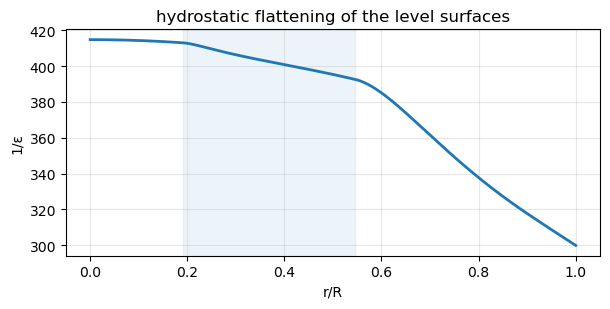

In [3]:
rr = range(1e-3, 1, length = 500)
fig, ax = subplots(figsize = (6.2, 3.2))
ax.plot(rr, [1/fl.ε(r) for r in rr], lw = 2)
ax.axvspan(r_ICB, r_CMB, color = "C0", alpha = 0.08)      # fluid outer core
ax.set_xlabel("r/R"); ax.set_ylabel("1/ε"); ax.grid(alpha = 0.3)
ax.set_title("hydrostatic flattening of the level surfaces")
tight_layout(); gcf()

## 2 · The compliances a solid inner core needs

Notebook 4's κ, ξ, γ, β describe two rotating pieces, mantle and fluid core. A solid inner core is a third, so the
set becomes a 3×3 matrix: three **regions** (whole Earth, fluid outer core, inner core) against three **forcing
channels** (the tidal potential, the outer core's wobble, the inner core's wobble).

$$\begin{array}{c|ccc} & \text{tidal} & \text{OC} & \text{IC} \\\\ \hline \text{whole} & \kappa & \xi & \zeta \\\\ \text{fluid} & \gamma & \beta & \delta \\\\ \text{IC} & \theta & \chi & \nu \end{array} \tag{2}$$

Each entry is one static body-force solve, read with `moment`. The top-left 2×2 is notebook 4's set. Betti
reciprocity ties the matrix across its diagonal, $\hat A_i S_{ij} = \hat A_j S_{ji}$ — three statements here,
returned as residuals.

In [4]:
c = sic_compliances(m; ic_layer = 1, oc_layer = 2, Ω_SI = Ω)
@printf("            tidal          OC            IC\n")
@printf("  whole   %+.4e   %+.4e   %+.4e\n", c.κ, c.ξ, c.ζ)
@printf("  fluid   %+.4e   %+.4e   %+.4e\n", c.γ, c.β, c.δ)
@printf("  IC      %+.4e   %+.4e   %+.4e\n", c.θ, c.χ, c.ν)
@printf("\nBetti residuals:  Â_tot·ξ=Â_f·γ %+.1e    Â_tot·ζ=Â_s·θ %+.1e    Â_f·δ=Â_s·χ %+.1e\n",
        c.recip.ξγ, c.recip.ζθ, c.recip.δχ)
@printf("inner core carries Â_s/Â_tot = %.2e of the moment\n", c.Âs/c.Ât)

            tidal          OC            IC
  whole   +1.0501e-03   +2.2414e-04   +5.6600e-09
  fluid   +1.9845e-03   +6.2263e-04   -5.2748e-07
  IC      +7.7556e-06   -8.1637e-05   +8.6641e-05

Betti residuals:  Â_tot·ξ=Â_f·γ -1.8e-12    Â_tot·ζ=Â_s·θ +8.4e-09    Â_f·δ=Â_s·χ -6.1e-11
inner core carries Â_s/Â_tot = 7.30e-04 of the moment


The inner-core column scales with the inner core's moment, 7×10⁻⁴ of the Earth's. The 2×2 subset agrees with
`compliances` to the last digit:

In [5]:
c2 = compliances(m; core_layer = 2, Ω_SI = Ω)
@printf("κ: %.6e vs %.6e      γ: %.6e vs %.6e\n", c.κ, c2.κ, c.γ, c2.γ)

κ: 1.050074e-03 vs 1.050074e-03      γ: 1.984454e-03 vs 1.984454e-03


## 3 · Inner core tilt

The inner core's *orientation* is a variable of its own: it can tilt relative to the mantle, and gravity pulls it
back. Three dimensionless couplings set the restoring torque (Dehant & Mathews eq. 7.152), all density-and-figure
quantities with no rigidity in them — $\alpha_1$ compares the inner core's figure to that of the fluid it displaces,
$\alpha_g$ is the gravitational stiffness of the surrounding mantle, and $\alpha_2 = \alpha_1 - \alpha_3\alpha_g$
with $\alpha_3 = 1 - \alpha_1$.

In [6]:
a = sic_alphas(m; ic_layer = 1, oc_layer = 2, Ω_SI = Ω)
@printf("        model    MHB\n")
@printf("  α₁  = %.3f    0.946\n", a.α1)
@printf("  α₂  = %.3f    0.829\n", a.α2)
@printf("  α₃  = %.3f    0.054\n", a.α3)
@printf("  α_g = %.3f    2.175\n", a.α_g)

        model    MHB
  α₁  = 0.947    0.946
  α₂  = 0.831    0.829
  α₃  = 0.053    0.054
  α_g = 2.176    2.175


## 4 · The four free modes

Mantle wobble $\tilde m$, fluid-core wobble $\tilde m_f$, inner-core wobble $\tilde m_s$ and inner-core tilt
$\tilde n_s$ give four angular-momentum equations, affine in the frequency: $M(\omega) = M_0 + \omega M_1$. The
free modes are the roots of $\det M(\omega) = 0$.

Two roots are nearly diurnal and retrograde in the terrestrial frame ($\omega \approx -1$), hence long-period
nutations in space: the **FCN**, the fluid core precessing inside its flattened cavity, and the **FICN**, the inner
core doing the same against gravity. The other two are slow wobbles — the **Chandler** wobble and the
**inner-core wobble**.

In [7]:
r = sic_nutation_modes(m; ic_layer = 1, oc_layer = 2, Ω_SI = Ω)
@printf("                        model      observed\n")
@printf("  FCN   (celestial)  %8.1f d    -430\n", r.FCN)
@printf("  FICN  (celestial)  %8.1f d    +475\n", r.FICN)
@printf("  CW    (wobble)     %8.1f d     433\n", r.CW)
@printf("  ICW   (wobble)     %8.1f d       —\n", r.ICW)

                        model      observed
  FCN   (celestial)    -457.7 d    -430
  FICN  (celestial)     473.3 d    +475
  CW    (wobble)        403.1 d     433
  ICW   (wobble)       2434.5 d       —


The **FICN** comes out of PREM's density and elasticity with no fitting anywhere in the chain.

The **FCN** is 28 d long because this is the *hydrostatic* figure: the real CMB is about 5 % more flattened than
equation (1) gives, and that excess is one of the few direct measurements of the deep Earth's departure from
hydrostatic equilibrium. The **Chandler** wobble is 30 d short because this Earth has no ocean; the pole tide
supplies the rest. The **ICW** has never been convincingly observed.

## 5 · The transfer function

The free modes are poles of the *forced* response. `sic_nutation_transfer` returns
$T(\omega) = \tilde m/\tilde m_{\rm rigid}$, the wobble relative to what a rigid Earth would do under the same
luni-solar torque: $T = 1$ is the rigid answer, a pole is a nutation the Earth amplifies.

Pass the whole frequency vector in one call. Assembling the 4×4 costs three forced solves and a Clairaut
integration, done once per call; a scalar loop over 600 points repeats that 600 times (~8 minutes, against 0.3 s).

In [ ]:
Tsid = 2π/Ω/86400                         # sidereal day [d]
ν2ω(P) = Tsid/P - 1.0                     # celestial period [d] → terrestrial ω
kwn = (ic_layer = 1, oc_layer = 2, Ω_SI = Ω)

Pr = range(-2000, -250, length = 600)     # retrograde branch, around the FCN
Pp = range(430, 520, length = 600)        # prograde branch, around the FICN
Tr = abs.(sic_nutation_transfer(m, ν2ω.(Pr); kwn...))
Tp = abs.(sic_nutation_transfer(m, ν2ω.(Pp); kwn...))

fig, ax = subplots(1, 2, figsize = (9.5, 3.4))
ax[1].plot(Pr, Tr, lw = 1.8); ax[1].set_yscale("log")
ax[1].axvline(r.FCN, color = "C3", ls = "--", lw = 1.2)
ax[1].set_title(@sprintf("retrograde: FCN at %.0f d", r.FCN))
ax[2].plot(Pp, Tp, lw = 1.8)
ax[2].axvline(r.FICN, color = "C2", ls = "--", lw = 1.2)
ax[2].set_title(@sprintf("prograde: FICN at %.0f d", r.FICN))
for x in ax; x.set_xlabel("celestial period [d]"); x.set_ylabel("|T|"); x.grid(alpha = 0.3); end
tight_layout(); gcf()

The left panel is logarithmic over two decades, the right linear over a few parts in 10⁴: the inner core torques
the mantle through its own moment of inertia, 7×10⁻⁴ of the whole.

The retrograde annual nutation sits at −365.26 d, on the shoulder of the FCN:

In [ ]:
Ta = abs(sic_nutation_transfer(m, ν2ω(-365.26); kwn...))
@printf("retrograde annual (-365.26 d):  |T| = %.4f   → %.1f%% above rigid\n", Ta, 100*(Ta - 1))